## Lab 7: Instruction Fine-Tuning

**Gruppe:** Phillip Graf, Konstantin Schmidt, Fabian Holländer

In diesem Lab importieren wir einen spezialisierten Datensatz für Instruction Tuning, führen die notwendigen Vorbereitungsschritte (Preprocessing) durch und trainieren das `GPT-2`-Modell von OpenAI so, dass es lernt, auf menschliche Anweisungen (Prompts) mit hilfreichen und passenden Antworten zu reagieren. Im letzen Schritt evaluieren wir das trainierte Modell automatisch mit dem Llama Modell.

---

### Unsere Datenquelle: Eigen generierter Instruction-Datensatz aus RecipeNLG

Für das Training nutzen wir einen **selbst erzeugten Instruction-Datensatz** auf Basis von **RecipeNLG**. Da kein Zugriff auf den RecipeNLG-Alpaca-Datensatz bestand, haben wir in `instruction_dataset.ipynb` eigene Prompts und Rezept-Antworten generiert. Die Antworten folgen dem im Pre-Training gelernten Format (Recipe: / Ingredients: / Directions:) und umfassen drei Instruktions-Typen: Titel → Rezept, Zutaten → Rezept sowie Titel + Zutaten → Rezept.

* **Erzeugung des Datensatzes:** [`instruction_dataset.ipynb`](instruction_dataset.ipynb)
* **Rohdaten-Quelle:** [RecipeNLG auf LRZ Sync & Share](https://syncandshare.lrz.de/dl/fiHE8nDPcb4nww3VCn4QmN/reduced_dataset_100k.csv)
* **Extrahierte Datensätze direkt zum Download:**
    * [Train](https://syncandshare.lrz.de/dl/fi7TGWhZKqmjF8Wsn9Ze9j/recipe_instruct_train_ctx512_seed123.jsonl)
    * [Validation](https://syncandshare.lrz.de/dl/fi89FcTYVkG4jNacPVJVMx/recipe_instruct_val_ctx512_seed123.jsonl)
    * [Test](https://syncandshare.lrz.de/dl/fiBKi9JVNvco2mPE1Kzgp5/recipe_instruct_test_ctx512_seed123.jsonl)
* **Referenz-Datensatz (nicht verwendet):** [Recipe NLG Alpaca](https://huggingface.co/datasets/AdamCodd/recipe-nlg-alpaca)
    

---

### Technisches Setup

Dieses Notebook wurde auf der Cloud-Plattform [**RunPod**](https://www.runpod.io) ausgeführt. Für das rechenintensive Instruction Fine-Tuning des `GPT-2`-Modells wurde erneut eine **NVIDIA RTX 6000** Grafikkarte genutzt.

Damit konnte das Training im Vergleich zu unserer lokaler Hardware drastisch beschleunigt und größere Batch-Größen ohne Speicherprobleme (Out-of-Memory) verarbeitet werden.

## Importieren notwendiger Python Bibliotheken


In [1]:
from functools import partial
from importlib.metadata import version
import io
import json
import random
import re
import time
import urllib.request

from sambanova import SambaNova
import requests
import tiktoken
import torch
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from utils.previous_chapters import GPTModel, load_weights_into_gpt, plot_losses
from utils.previous_chapters import (
    generate,
    text_to_token_ids,
    token_ids_to_text,
    calc_loss_loader,
    train_model_simple
)
from utils.gpt_download import download_and_load_gpt2

tokenizer = tiktoken.get_encoding("gpt2")
torch.manual_seed(123)

pkgs = [
    "numpy",       # PyTorch & TensorFlow dependency
    "matplotlib",  # Plotting library
    "tiktoken",    # Tokenizer
    "torch",       # Deep learning library
    "tqdm",        # Progress bar
    "tensorflow",  # For OpenAI's pretrained weights
]
for p in pkgs:
    print(f"{p} version: {version(p)}")

I0000 00:00:1781565699.674511    2498 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781565699.721101    2498 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781565700.682844    2498 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


numpy version: 2.1.2
matplotlib version: 3.11.0
tiktoken version: 0.13.0
torch version: 2.8.0+cu128
tqdm version: 4.68.2
tensorflow version: 2.21.0


## Datensätze vorbereiten

Wir laden die drei bereits getrennt erzeugten JSONL-Dateien (Train / Validation / Test)
direkt von der LRZ Cloud — erzeugt in `instruction_dataset.ipynb` aus RecipeNLG.
Für schnelleres Testen/Training werden nur die **ersten 1.000 / 100 / 100** Einträge geladen.
Das Test-Set enthält nur User-Prompts (ohne Referenz-Antwort) für das spätere Inferenz-Testing.


In [2]:
def load_jsonl_from_url(url, max_entries=None):
    """
    Lädt eine JSONL-Datei direkt aus dem Internet in den Arbeitsspeicher,
    ohne sie lokal auf der Festplatte zwischenzuspeichern.
    """
    data = []
    print(f"Lade Daten direkt von URL: {url} ...")
    try:
        req = urllib.request.Request(
            url, 
            headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
        )
        
        with urllib.request.urlopen(req) as response:
            text_stream = io.StringIO(response.read().decode('utf-8'))
            
            for i, line in enumerate(text_stream):
                if max_entries and i >= max_entries:
                    break
                data.append(json.loads(line))
                
        return data
    except Exception as e:
        print(f"Fehler beim Laden der Daten von {url}: {e}")
        return []

# Nur die ersten N Einträge laden (schnelleres Training/Testing)
N_TRAIN = 1_000
N_VAL   = 100
N_TEST  = 100

url_train = "https://syncandshare.lrz.de/dl/fi7TGWhZKqmjF8Wsn9Ze9j/recipe_instruct_train_ctx512_seed123.jsonl"
url_val   = "https://syncandshare.lrz.de/dl/fi89FcTYVkG4jNacPVJVMx/recipe_instruct_val_ctx512_seed123.jsonl"
url_test  = "https://syncandshare.lrz.de/dl/fiBKi9JVNvco2mPE1Kzgp5/recipe_instruct_test_ctx512_seed123.jsonl"

recipe_data_train = load_jsonl_from_url(url_train, max_entries=N_TRAIN)
recipe_data_val   = load_jsonl_from_url(url_val,   max_entries=N_VAL)
recipe_data_test  = load_jsonl_from_url(url_test,  max_entries=N_TEST)

print(f"\nTrain:      {len(recipe_data_train)} Einträge (max {N_TRAIN})")
print(f"Validation: {len(recipe_data_val)} Einträge (max {N_VAL})")
print(f"Test:       {len(recipe_data_test)} Einträge (max {N_TEST})")

example_idx = 0 if len(recipe_data_train) == 0 else min(99, len(recipe_data_train) - 1)
if recipe_data_train:
    print("\nBeispiel Train-Eintrag:\n", recipe_data_train[example_idx], "\n")
if recipe_data_test:
    print("Beispiel Test-Eintrag (nur User-Prompt):\n", recipe_data_test[0], "\n")


Lade Daten direkt von URL: https://syncandshare.lrz.de/dl/fi7TGWhZKqmjF8Wsn9Ze9j/recipe_instruct_train_ctx512_seed123.jsonl ...
Lade Daten direkt von URL: https://syncandshare.lrz.de/dl/fi89FcTYVkG4jNacPVJVMx/recipe_instruct_val_ctx512_seed123.jsonl ...
Lade Daten direkt von URL: https://syncandshare.lrz.de/dl/fiBKi9JVNvco2mPE1Kzgp5/recipe_instruct_test_ctx512_seed123.jsonl ...

Train:      1000 Einträge (max 1000)
Validation: 100 Einträge (max 100)
Test:       100 Einträge (max 100)

Beispiel Train-Eintrag:
 {'conversations': ['Write a full recipe for The Most Delicious Maple Glazed Pork Loin using pork loin, barbecue sauce, ground ginger, orange rind, maple syrup.', 'Recipe: The Most Delicious Maple Glazed Pork Loin\nIngredients:\n1 (3 lb) boneless pork loin\n1 teaspoon ground ginger\n1/2 teaspoon salt\n1/2 cup barbecue sauce\n1/4 cup maple syrup\n2 teaspoons grated orange rind\nDirections:\nRub pork loin with mixture of ginger and salt.\nInsert meat thermometer in the thickest part 

## 7.1 Alpaca vs Phi-3

Bevor wir die Daten in das Modell füttern, müssen wir das Format herausfinden und richtig formatieren. Datensätze liegen selten direkt in dem Format vor, das ein bestimmtes Modell erwartet. Zwei der bekanntesten historischen und modernen Formate sind **Alpaca** und **Phi-3**:

![image.png](attachment:image.png)
*Quelle: [Sebastian Raschka - LLMs from scratch (Ch. 7)](https://sebastianraschka.com/images/LLMs-from-scratch-images/ch07_compressed/04.webp?2)*

---

## 7.2 Transformation in Phi-3
Unser gewählter **LIMA-Datensatz** liegt im Original als rohes JSON-Konversations-Array vor und wir müssen diesen erstmal in das **Phi-3** Format bekommen. Hier ist eine typische Beispielzeile:

```json
{
  "conversations": [
    "How to send HTML-formatted email in C#?", 
    "Setting isBodyHtml to true allows you to use HTML tags in the message body:\n```\nmsg = new MailMessage(\"xxxx@gmail.com\", ..."
  ]
}

Im folgenden bringen wir mit der Funktion `format_input_phi3` die rohen JSONL-Daten durch zwei zentrale Mechanismen in die finale Phi-3-Struktur mit `<|user|>`, als Fragen bzw. Instruktionen und Antworten des Modells mit dem Tag `<|assistant|>`.

In [3]:
# Funktion die die Daten in das gewünschte Format bringt
def format_input_phi3(entry, include_response=True):
    # Gesprächsliste extrahieren: gerade Indizes = User, ungerade = Assistent
    conversations = entry["conversations"]

    # Bei include_response=False letzte Assistenten-Antwort weglassen
    messages = conversations if include_response else conversations[:-1]

    formatted = ""
    # Abwechselnd User- und Assistenten-Nachrichten aufbauen
    for i, message in enumerate(messages):
        if i % 2 == 0:
            # Gerade Indizes sind User-Nachrichten
            formatted += f"<|user|>\n{message}\n\n"
        else:
            # Ungerade Indizes sind Assistenten-Antworten
            formatted += f"<|assistant|>\n{message}"

    return formatted


# Beispiel: nur Input (ohne Antwort)
print("=== Nur Input ===")
print(format_input_phi3(recipe_data_train[example_idx], include_response=False))

print("\n=== Input + Response ===")
print(format_input_phi3(recipe_data_train[example_idx], include_response=True))

=== Nur Input ===
<|user|>
Write a full recipe for The Most Delicious Maple Glazed Pork Loin using pork loin, barbecue sauce, ground ginger, orange rind, maple syrup.



=== Input + Response ===
<|user|>
Write a full recipe for The Most Delicious Maple Glazed Pork Loin using pork loin, barbecue sauce, ground ginger, orange rind, maple syrup.

<|assistant|>
Recipe: The Most Delicious Maple Glazed Pork Loin
Ingredients:
1 (3 lb) boneless pork loin
1 teaspoon ground ginger
1/2 teaspoon salt
1/2 cup barbecue sauce
1/4 cup maple syrup
2 teaspoons grated orange rind
Directions:
Rub pork loin with mixture of ginger and salt.
Insert meat thermometer in the thickest part of the pork loin.
Arrange hot coals around drip pan in covered grill; place the pork loin fat side up on grill rack over drip pan.
Grill with the lid down for 2-2 1/2 hours or to 170 degrees on meat thermometer.
Baste frequently with mixture of barbeque sauce, maple syrup and orange rind during the last hour of cooking.
Remove 

In [4]:
# Formatieren der Datensätze für Training, Validation und Test
formatted_train = [format_input_phi3(entry) for entry in recipe_data_train]
formatted_val   = [format_input_phi3(entry) for entry in recipe_data_val]
formatted_test  = [format_input_phi3(entry) for entry in recipe_data_test]

# Beispiel: einige formatierte Trainings-Einträge
for entry in formatted_train[example_idx:example_idx + 3]:
   print(entry, "\n\n")


<|user|>
Write a full recipe for The Most Delicious Maple Glazed Pork Loin using pork loin, barbecue sauce, ground ginger, orange rind, maple syrup.

<|assistant|>
Recipe: The Most Delicious Maple Glazed Pork Loin
Ingredients:
1 (3 lb) boneless pork loin
1 teaspoon ground ginger
1/2 teaspoon salt
1/2 cup barbecue sauce
1/4 cup maple syrup
2 teaspoons grated orange rind
Directions:
Rub pork loin with mixture of ginger and salt.
Insert meat thermometer in the thickest part of the pork loin.
Arrange hot coals around drip pan in covered grill; place the pork loin fat side up on grill rack over drip pan.
Grill with the lid down for 2-2 1/2 hours or to 170 degrees on meat thermometer.
Baste frequently with mixture of barbeque sauce, maple syrup and orange rind during the last hour of cooking.
Remove to serving platter and cut into thin slices.
Garnish with red grapes, green grapes and parsley sprigs (optional). 


<|user|>
Suggest a dish I can make with buttermilk, pecans, margarine, vanilla

## Erstellen der Datensätze für das Modell Training

Train, Validation und Test wurden bereits in `instruction_dataset.ipynb` getrennt erzeugt.
Hier nutzen wir jeweils nur die ersten **1.000 / 100 / 100** Einträge — ein zusätzlicher
Random-Split ist daher nicht nötig.


In [5]:
# Bereits getrennte Datensätze direkt übernehmen (kein 95/5-Split mehr nötig)
train_data = recipe_data_train
val_data   = recipe_data_val
test_data  = recipe_data_test

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")


Train: 1000, Val: 100, Test: 100


## Datensätze in Trainingbatches organisieren


- Die Datensätze werden in folgenden Schritten in Batches organisiert
    1. Daten in das Prompttamplate formateren (bereits geschehen)
    2. Formatierte Daten in Token IDs konvertieren
    3. Batches mit Padding Tokens in die gleiche länge bringen
    4. Target TokenIDs generieren
    5. irrelevante Padding Tokens maskieren

In [6]:
class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        self.encoded_texts = []
        for entry in data:
            full_text = format_input_phi3(entry, include_response=True)
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

train_dataset = InstructionDataset(train_data, tokenizer)
val_dataset = InstructionDataset(val_data, tokenizer)
test_dataset = InstructionDataset(test_data, tokenizer)

print (f"Beispiel tokenisierter Eintrag:\n{train_dataset[example_idx]}")


Beispiel tokenisierter Eintrag:
[27, 91, 7220, 91, 29, 198, 16594, 257, 1336, 8364, 329, 383, 4042, 39528, 21249, 2671, 13865, 44062, 6706, 259, 1262, 18128, 2376, 259, 11, 36646, 10746, 11, 2323, 25072, 11, 10912, 374, 521, 11, 31377, 24208, 13, 198, 198, 27, 91, 562, 10167, 91, 29, 198, 37523, 25, 383, 4042, 39528, 21249, 2671, 13865, 44062, 6706, 259, 198, 41222, 25, 198, 16, 357, 18, 18360, 8, 5351, 5321, 18128, 2376, 259, 198, 16, 22326, 2323, 25072, 198, 16, 14, 17, 22326, 8268, 198, 16, 14, 17, 6508, 36646, 10746, 198, 16, 14, 19, 6508, 31377, 24208, 198, 17, 47234, 1036, 515, 10912, 374, 521, 198, 13470, 507, 25, 198, 21312, 18128, 2376, 259, 351, 11710, 286, 25072, 290, 8268, 13, 198, 44402, 6174, 21969, 15635, 287, 262, 6546, 395, 636, 286, 262, 18128, 2376, 259, 13, 198, 3163, 9521, 3024, 763, 874, 1088, 36296, 3425, 287, 5017, 29901, 26, 1295, 262, 18128, 2376, 259, 3735, 1735, 510, 319, 29901, 19127, 625, 36296, 3425, 13, 198, 8642, 359, 351, 262, 19789, 866, 329, 362, 12,

## Dynamisches Padding für die Inputs

Damit wir mehrere Beispiele parallel in einem Batch verarbeiten können, müssen alle Sequenzen dieselbe Länge haben. In den folgenden Zellen erarbeiten wir uns gemeinsam eine effiziente Funktion, welche die Daten (Input, sowie Targets) auf ein einheitliches Maß bringen:

Wie bereits in den Kapiteln davor beschrieben nutzen wir hier auch wieder den Ansatz des Auffüllens. Kürzere Sequenzen (wie `inputs_2` und `inputs_3`) werden mit dem `<|endoftext|>`-Token (`50256`) aufgefüllt, bis sie die Maximallänge des Batches erreichen.

**Ergebnis:** Alle drei ungleich langen Listen werden in eine symmetrische Matrix (Tensor) transformiert und am Ende mit `50256` aufgefüllt.

In [7]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # längste Sequenz im Batch finden und um +1 erhöhen, 
    # um Platz für einen zusätzlichen Padding-Token zu schaffen
    batch_max_length = max(len(item)+1 for item in batch)

    inputs_lst = []

    # für jedes Element im Batch: Kopie erstellen, <|endoftext|> 
    # Token hinzufügen, auf batch_max_length auffüllen
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )
        # mit padded[:-1] entfernen wir den zusätzlichen gepaddeten Token,
        # dass der durch die +1 Einstellung in batch_max_length hinzugefügt wurde
        # (der extra padding token wird in späteren Codes relevant sein)
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    # liste von inputs in Tensor umwandeln
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [8]:
# Beispiel wie das Padding funktioniert und die kürzesten batchesn autoamtisch mit Special Tokes auffüllt
inputs_1 = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4,     5,     6,     7,     8,     9],
        [    5,     6, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256, 50256, 50256, 50256, 50256, 50256]])


## Padding auch beim Target

Für das Training benötigen wir neben den Inputs auch die exakt passenden Zielwerte (Targets).

* **Input-Tensor:** Die Sequenz wird ohne das allerletzte Padding-Token genommen.

* **Target-Tensor:** Die Sequenz wird um genau eine Position nach rechts verschoben. Das Modell lernt so, bei jedem Input-Token das jeweils nachfolgende Target-Token vorherzusagen.

**Ergebnis** Der Target-Tensor spiegelt den Input wider, ist jedoch um ein Element versetzt. Das erste Element der Eingabe fehlt im Target, dafür wird hinten ein Padding-Token angehangen.

In [9]:
# Das selbe padding nur auch für den Target batch
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # längste Sequenz im Batch finden und um +1 erhöhen, 
    # um Platz für einen zusätzlichen Padding-Token zu schaffen
    batch_max_length = max(len(item)+1 for item in batch)

    inputs_lst = []
    targets_lst = []

    # für jedes Element im Batch: Kopie erstellen, <|endoftext|> 
    # Token hinzufügen, auf batch_max_length auffüllen
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )

        inputs = torch.tensor(padded[:-1])  # Eingabesequenz ohne den zusätzlichen gepaddeten Token
        targets = torch.tensor(padded[1:])  # Zielsequenz, um 1 nach rechts verschoben (für next-token prediction)

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # liste von inputs und targets in Tensor umwandeln
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [10]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4,     5,     6,     7,     8,     9],
        [    5,     6, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256, 50256, 50256, 50256, 50256, 50256]])
tensor([[    1,     2,     3,     4,     5,     6,     7,     8,     9, 50256],
        [    6, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256]])


## Effizienz durch den Ignore-Index

Wenn ein Modell zu viele Padding-Tokens berechnet, lernt es nichts Sinnvolles und verfälscht den Loss. 

Dafür haben wir aus den Funktion von oben nun die unsere finale Funktion erstellt:

* **Maskierung mit `-100`:** PyTorch besitzt die Eigenschaft, das Label `-100` beim Berechnen der `cross_entropy` standardmäßig komplett zu ignorieren. Die Funktion ersetzt daher alle überflüssigen Padding-Tokens im Target-Tensor durch `-100`.

* **Wichtig** ist, dass das *erste* `<|endoftext|>`-Token (`50256`) **nicht** ersetzt wird. Das Modell muss zwingend lernen, wann eine Antwort vorbei ist, um zu erkennen, wenn es mit der Generierung aufhören soll.

In [11]:
# Das padding nochmal erweitert in dem man die Target Tensoren auf -100 setzt als zeichen für ein Ignore Index. Was auch immer das ist?
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=None,
    device="cpu"
):
   # längste Sequenz im Batch finden und um +1 erhöhen, 
    # um Platz für einen zusätzlichen Padding-Token zu schaffen
    batch_max_length = max(len(item)+1 for item in batch)

    inputs_lst = []
    targets_lst = []

    # für jedes Element im Batch: Kopie erstellen, <|endoftext|> 
    # Token hinzufügen, auf batch_max_length auffüllen
    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]
        padded = (
            new_item + [pad_token_id] *
            (batch_max_length - len(new_item))
        )

        
        inputs = torch.tensor(padded[:-1])  # Eingabesequenz ohne den zusätzlichen gepaddeten Token
        targets = torch.tensor(padded[1:])  # Zielsequenz, um 1 nach rechts verschoben (für next-token prediction)

        # alle Zielpositionen, die auf den pad_token_id zeigen, auf ignore_index setzen, außer der ersten
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # optional: Eingabe- und Zielsequenzen auf allowed_max_length kürzen
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Liste von inputs und targets in Tensor umwandeln
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [12]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4,     5,     6,     7,     8,     9],
        [    5,     6, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256, 50256, 50256, 50256, 50256, 50256]])
tensor([[    1,     2,     3,     4,     5,     6,     7,     8,     9, 50256],
        [    6, 50256,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100,  -100,  -100,  -100,  -100,  -100]])


Das folgende Beispiel zeigt, dass der Ignore Index funktioniert.

* **Vergleich von `loss_1` und `loss_2`:**  
Fügt man einem Batch ein drittes, normales Beispiel hinzu (`targets_2 = [0, 1, 1]`), ändert sich der Gesamt-Loss von `1.1269` auf `0.7936`. Das zusätzliche Beispiel beeinflusst das Training.

* **Der Effekt von `-100` (`loss_3`):**  
Ersetzt man das Label des dritten Beispiels durch den Ignore-Index (`targets_3 = [0, 1, -100]`), bleibt der Loss exakt bei `1.1269` (`loss_1 == loss_3: True`).

* **Fazit:**  
Dank `-100` "sieht" die Loss-Funktion die künstlich aufgefüllten Padding-Bereiche nicht. Das Modell wird nur für echte Textinhalte und das finale Stopp-Signal bestraft oder belohnt.

In [13]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],  # 1st training example
     [-0.5, 1.5]]  # 2nd training example
)
targets_1 = torch.tensor([0, 1])


loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [14]:
# weitere beispiel
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.5, 1.5]]  # New 3rd training example
)
targets_2 = torch.tensor([0, 1, 1])

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7936)


In [15]:
targets_3 = torch.tensor([0, 1, -100])

loss_3 = torch.nn.functional.cross_entropy(logits_2, targets_3)
print(loss_3)
print("loss_1 == loss_3:", loss_1 == loss_3)

tensor(1.1269)
loss_1 == loss_3: tensor(True)


## Dataloader
Im nächsten Abschnitt laden wir nun mit unserem Dataloader aus den vorherigen Kapiteln und unsere Padding Funktion von oben nun die Datensätz, um diese dann für das Training des Modells verwenden zu können.

In [16]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

Device: cuda


In [17]:
customized_collate_fn = partial(
    custom_collate_fn,
    device=device,
    allowed_max_length=1024
)

In [18]:
num_workers = 0
batch_size = 8

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [19]:
# checks and validations
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)
print("")
print("Inputs:", inputs[0], end="\n\n")
print("Targets:", targets[0], end="\n\n")

Train loader:
torch.Size([8, 407]) torch.Size([8, 407])
torch.Size([8, 261]) torch.Size([8, 261])
torch.Size([8, 356]) torch.Size([8, 356])
torch.Size([8, 464]) torch.Size([8, 464])
torch.Size([8, 315]) torch.Size([8, 315])
torch.Size([8, 296]) torch.Size([8, 296])
torch.Size([8, 459]) torch.Size([8, 459])
torch.Size([8, 506]) torch.Size([8, 506])
torch.Size([8, 462]) torch.Size([8, 462])
torch.Size([8, 376]) torch.Size([8, 376])
torch.Size([8, 288]) torch.Size([8, 288])
torch.Size([8, 416]) torch.Size([8, 416])
torch.Size([8, 338]) torch.Size([8, 338])
torch.Size([8, 497]) torch.Size([8, 497])
torch.Size([8, 248]) torch.Size([8, 248])
torch.Size([8, 263]) torch.Size([8, 263])
torch.Size([8, 355]) torch.Size([8, 355])
torch.Size([8, 424]) torch.Size([8, 424])
torch.Size([8, 312]) torch.Size([8, 312])
torch.Size([8, 438]) torch.Size([8, 438])
torch.Size([8, 246]) torch.Size([8, 246])
torch.Size([8, 322]) torch.Size([8, 322])
torch.Size([8, 248]) torch.Size([8, 248])
torch.Size([8, 364])

In [20]:
import json
import os
import numpy as np
import requests
import tensorflow as tf
from tqdm import tqdm


def download_gpt2_backblaze(model_size="355M", models_dir="gpt2"):
    """Lädt die GPT-2 Gewichte über Backblaze und gibt settings + params zurück."""

    base_url = (
        f"https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2/{model_size}"
    )

    filenames = [
        "checkpoint",
        "encoder.json",
        "hparams.json",
        "model.ckpt.data-00000-of-00001",
        "model.ckpt.index",
        "model.ckpt.meta",
        "vocab.bpe",
    ]

    model_dir = os.path.join(models_dir, model_size)
    os.makedirs(model_dir, exist_ok=True)

    print(f"🚀 Starte Direkt-Download von Backblaze für GPT-2 ({model_size})...")

    for filename in filenames:
        url = f"{base_url}/{filename}"
        destination = os.path.join(model_dir, filename)

        # Prüfen, ob die Datei schon da ist
        if os.path.exists(destination):
            response = requests.head(url)
            total_size = int(response.headers.get("content-length", 0))
            if os.path.getsize(destination) == total_size:
                continue

        # Download mit 1MB Chunks
        response = requests.get(url, stream=True)
        response.raise_for_status()
        total_size = int(response.headers.get("content-length", 0))

        with open(destination, "wb") as file:
            with tqdm(
                total=total_size, unit="iB", unit_scale=True, desc=filename
            ) as bar:
                for chunk in response.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        file.write(chunk)
                        bar.update(len(chunk))

    print(f"\n[SUCCESS] Modell {model_size} heruntergeladen!")
    print("📦 Konvertiere Gewichte aus TensorFlow...")

    # --- HIER IST DER GEFEHLTE TEIL ---
    # Neuesten Checkpoint ermitteln und hparams laden
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(
        open(os.path.join(model_dir, "hparams.json"), "r", encoding="utf-8")
    )

    # Die Gewichte extrahieren (greift auf die Funktion aus dem Buch zurück)
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    # Wichtig für Zeile 17 in deinem Code!
    return settings, params


def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    """Original-Funktion aus dem Buch zum Extrahieren der TF-Gewichte."""
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}
    for name, _ in tf.train.list_variables(ckpt_path):
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))
        variable_name_parts = name.split("/")[1:]
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array
    return params

## Laden des vortrainierten Modells

Da für diesen Anwendungsfall das kleinste gpt2 Modell leider zu klein ist. Wechseln wir im Gegensatz zum Kapitel 6 auf das nächste größere gpt2-medium Modell.

In [21]:
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_gpt2_backblaze(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval()
model.to(device)

🚀 Starte Direkt-Download von Backblaze für GPT-2 (355M)...

[SUCCESS] Modell 355M heruntergeladen!
📦 Konvertiere Gewichte aus TensorFlow...


GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=1024, out_features=1024, bias=True)
        (W_key): Linear(in_features=1024, out_features=1024, bias=True)
        (W_value): Linear(in_features=1024, out_features=1024, bias=True)
        (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU()
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_f

Im nächsten Abschnitt schauen wir uns an wie das untrainierte Modell abschneidet. Am Ergebnis kann man sehen, dass es noch nichts gelernt hat und einfach den Input wiederholt und ausgibt.


In [22]:
# 1. Input-Text vorbereiten und anzeigen
input_text = format_input_phi3(val_data[37])

print("INPUT TEXT:")
print(input_text)
print("\n" + "="*50 + "\n")

# 2. Token-Generierung ausführen
token_ids = generate(
    model=model,
    idx=text_to_token_ids(input_text, tokenizer),
    max_new_tokens=35,
    context_size=BASE_CONFIG["context_length"],
    eos_id=50256,
)
generated_text = token_ids_to_text(token_ids, tokenizer)

# 3. Input-Text entfernen und Antwort extrahieren
response_text = (
    generated_text[len(input_text):]
    .replace("<|assistant|>", "")
    .strip()
)

# 4. Ergebnis anzeigen
print("RESPONSE TEXT (Exklusive Input):")
print(response_text)

INPUT TEXT:
<|user|>
Build a dish around anise, cherry tomatoes, salt, vegetable oil, black pepper, chili pepper and give me the recipe.

<|assistant|>
Recipe: Anise and Cherry Tomatoes Salad With a Kick
Ingredients:
3 cups anise
2 cups cherry tomatoes
1 teaspoon chili pepper flakes (optional)
1 teaspoon salt
12 teaspoon black pepper
12 cup white balsamic vinegar
14 cup vegetable oil
Directions:
This salad is best made the night before and marinated in refrigerator.
This way the flavors all blend.
Have ready a bowl to add your veggies and to mix your salad.
You will also need a med size tupperware bowl with tight lid.
Wash the anise bulbs and slice off the end (where roots was) and the top stalks, but don't throw them out.
Slice the bulb lengthwise and chop like an onion.
Reserve some of the green leaves to add to the salad.
Chop the stalks as well into bite size pieces.
Wash and cut your cherry tomatoes in half and add to bowl with anise.
To this add the rest of your ingredients.
Mix 

Den Start Loss bzw. Baseline Loss berechnen:

In [23]:
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 2.6598672389984133
Validation loss: 2.5607852935791016


## 7.3 Training

Nun kommen wir bereits zum Training. Wir bereits Kapitel 6 auch haben wir das Training auf der Cloud-Plattform [**RunPod**](https://www.runpod.io) ausgeführt. Für das rechenintensive Feintuning des `GPT-2`-Modells wurde eine **NVIDIA RTX 6000** Grafikkarte genutzt. 

In [24]:
start_time = time.time()

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 10

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input_phi3(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.329, Val loss 2.347
Ep 1 (Step 000005): Train loss 2.155, Val loss 2.126
Ep 1 (Step 000010): Train loss 1.923, Val loss 2.041
Ep 1 (Step 000015): Train loss 1.968, Val loss 2.010
Ep 1 (Step 000020): Train loss 1.935, Val loss 2.004
Ep 1 (Step 000025): Train loss 1.870, Val loss 1.993
Ep 1 (Step 000030): Train loss 1.784, Val loss 1.967
Ep 1 (Step 000035): Train loss 1.814, Val loss 1.946
Ep 1 (Step 000040): Train loss 1.853, Val loss 1.941
Ep 1 (Step 000045): Train loss 1.610, Val loss 1.928
Ep 1 (Step 000050): Train loss 1.674, Val loss 1.916
Ep 1 (Step 000055): Train loss 1.692, Val loss 1.907
Ep 1 (Step 000060): Train loss 1.812, Val loss 1.904
Ep 1 (Step 000065): Train loss 1.579, Val loss 1.900
Ep 1 (Step 000070): Train loss 1.707, Val loss 1.894
Ep 1 (Step 000075): Train loss 1.715, Val loss 1.889
Ep 1 (Step 000080): Train loss 1.706, Val loss 1.882
Ep 1 (Step 000085): Train loss 1.697, Val loss 1.880
Ep 1 (Step 000090): Train loss 1.582, Val loss

In [25]:
file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium355M-sft.pth


## 7.4 Validierung des Trainings

Wie wir bereits im Trainingsverlauf gesehen haben und auch nochmal im folgenden Plot sichtbar wird, hat sich zwar der Trainings Loss stetig verbessert, aber der Validierungs Loss dafür stetig verschlechtert. Dies könnte auf ein Overfitting hindeuten.

Wenn wir uns allerdings weiter unten die Antworten anschauen die das Modell gibt, hat es sich deutlich verbessert zu "ohne" Training.

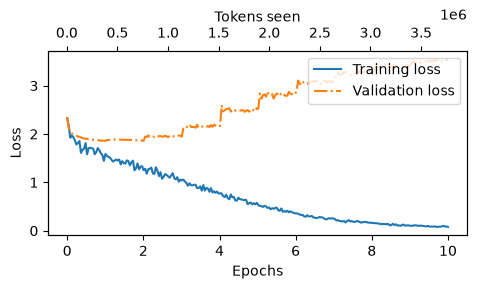

In [26]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

### Erste Erkenntnisse aus den Modell-Antworten

Wenn wir die generierten Antworten betrachten, lassen sich bereits deutliche Fortschritte im Vergleich zum Basismodell erkennen:

- **Erfolgreiches Struktur-Lernen:** Das feingetunte Modell hat die zugrundeliegende Chat-Struktur (`<|user|>` und `<|assistant|>`) verstanden. Es reagiert nun korrekt auf Instruktionen und gibt die Antworten formatiert aus.

- **Thematische Relevanz:** Auch inhaltlich bewegen sich die Antworten zumindest schon in den richtigen Themenfeldern.

- **Deutliche Steigerung:** Im Vergleich zum untrainierten Modell, das im vorherigen Schritt lediglich den Input stupide wiederholt hat, ist das ein massiver Qualitätssprung.

**Wichtige Einschränkung:** Auch wenn die Struktur stimmt, zeigt die spätere Evaluierung durch das LLama Modell, dass die inhaltlichen Fakten leider noch falsch sind.

In [27]:
for entry in test_data[:3]:

    input_text = format_input_phi3(entry)

    prompt = input_text + "<|assistant|>\n"

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(prompt, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    
    response_text = (
        generated_text[len(prompt):]
        .replace("<|assistant|>", "")
        .strip()
    )
    
    print(input_text)
    print(f"\nModel response:\n>> {response_text}")
    print("-------------------------------------")

<|user|>
Make a recipe using salt, bread machine yeast, onion powder, onion, butter, brown sugar, bread flour, milk, black pepper, water.



Model response:
>> Recipe: Zucchini Bread
Ingredients:
1 lb. fresh zucchini
1/2 lb. dried zucchini
1 c. brown sugar
1/2 c. milk
1 tsp. salt
1 tsp. onion powder
1 tsp. dried bread crumbs
1 c. melted butter
1 c. chopped onion
Directions:
Cook zucchini in boiling water until tender.
Drain.
Melt butter in large skillet over medium heat?
Add zucchini; cook until tender.
Add sugar, brown sugar, milk, salt and onion powder.
Cook until thick.
Stir in bread crumbs and melted butter.
Add liquid from skillet and milk.
Cook until thick.
Can be frozen.
-------------------------------------
<|user|>
How do I make Basmati Pilaf Recipe with water, basmati rice, salt, black mustard seeds?



Model response:
>> Recipe: Basmati Pilaf Recipe
Ingredients:
1/2 cup chopped onion
2 tablespoons coriander leaves
2 tablespoons chopped green chili
1 1/2 cups rice hulled
1/2 

Wir lassen das Modell nun auf unseren gesamten Test Datensatz laufen und speichern uns die Antworten zu den Instructions strukturiert in einer JSON Datei ab. Um mit dieser in den folgenden Schritten, dass Modell automatisch von LLama evaluieren zu lassen.

In [29]:
for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input_phi3(entry)
    prompt = input_text + "<|assistant|>\n"

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(prompt, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    
    response_text = (
        generated_text[len(prompt):]
        .replace("<|assistant|>", "")
        .strip()
    )

    entry["model_response"] = response_text


with open("output/instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)

100%|██████████| 100/100 [02:49<00:00,  1.69s/it]


## 7.5 Evaluierung mit LLM-as-a-Judge

Die Evaluierung von generativen Sprachmodellen (LLMs) unterscheidet sich grundlegend von klassischen Klassifikationsmodellen. Da das Modell Text generiert, gibt es keine einfache mathematische "Genauigkeit" (Accuracy) oder "Noten". 

Eine Antwort kann faktisch absolut korrekt, aber völlig anders formuliert sein als der hinterlegte Vergleichstext. Umgekehrt haben wir oben gesehen: Eine Antwort kann strukturell perfekt aussehen, inhaltlich aber komplett am Thema vorbeigehen (Halluzination). **Wann ist ein LLM also gut und wann schlecht?**

Um diese Frage objektiv und skalierbar zu beantworten, nutzen wir das Prinzip **"LLM-as-a-Judge"** (LLM als Richter). Dabei lassen wir die generierten Antworten unseres selbst trainierten, kleineren Modells von einem deutlich größeren, hochentwickelten Sprachmodell analysieren und bewerten.

---

### Technisches Setup & Hardware-Anpassung

* **Ursprünglicher Plan:** Lokale Evaluierung über ein **Llama-3-8B** Modell mittels **Ollama**.
* **Die Herausforderung:** Die lokalen Hardware-Ressourcen reichten für eine flüssige und effiziente Evaluierung der Datenmengen nicht aus.
* **Die Lösung:** Umstieg auf eine API Anbindung zu einem externen Modell über die Cloud-API von [SambaNova](https://sambanova.ai). Über diese Plattform greifen wir auf das das **Llama-3.3-70B** Modell von Meta zur Bewertung zu.

In [ ]:
%pip install sambanova

In [30]:
from sambanova import SambaNova

SAMBANOVA_API_KEY = "912c801b-fd39-4753-9080-384032adbc80" # Ersetze durch deinen tatsächlichen API-Schlüssel
FILE_PATH = "output/instruction-data-with-response.json"

In [31]:
with open(FILE_PATH, "r") as file:
    test_data = json.load(file)

print(f"Erfolgreich {len(test_data)} Test-Einträge geladen.")

def format_input(entry):
    return format_input_phi3(entry)

Erfolgreich 100 Test-Einträge geladen.


In [32]:
client = SambaNova(
    api_key="fb3cb084-4c11-47fa-9d41-65e5ba1407f1", # bitte eigenen API Key hinzufügen
    base_url="https://api.sambanova.ai/v1",
)

def query_model(
    prompt,
    model="Meta-Llama-3.3-70B-Instruct" 
):
    
    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "user", "content": prompt}
        ],
        temperature=0.1,
        top_p=0.1
    )
    
    return response.choices[0].message.content


try:
    test_res = query_model("What do Llamas eat?")
    print("Cloud API erfolgreich mit offiziellem Client getestet! Antwort:")
    print(">>", test_res)
except Exception as e:
    print(f"Fehler bei der API-Verbindung mit der offiziellen Bibliothek: {e}")

Cloud API erfolgreich mit offiziellem Client getestet! Antwort:
>> Llamas are herbivores, which means they primarily eat plants and plant-based foods. Their diet consists of:

1. **Grasses**: Llamas love to graze on various types of grasses, including timothy grass, orchard grass, and brome grass.
2. **Hay**: High-quality hay, such as alfalfa hay or grass hay, is a staple in a llama's diet. Hay provides essential fiber, vitamins, and minerals.
3. **Leaves**: Llamas enjoy munching on leaves from trees and shrubs, like willow, oak, and maple.
4. **Fruits and vegetables**: Llamas can eat a variety of fruits and vegetables, such as apples, carrots, and sweet potatoes, in moderation.
5. **Grains**: Llamas may receive grains like oats, corn, or barley as a supplement, but these should be limited to avoid digestive issues.
6. **Minerals and vitamins**: Llamas require access to mineral supplements, like salt and calcium, to ensure they're getting all the necessary nutrients.

It's essential to

### Erkenntnisse aus der automatisierten Evaluierung

Die Auswertung der 3 ersten Testbeispiele liefert ein ernüchterndes, aber extrem lehrreiches Ergebnis: Das deutlich größere und besser trainierte **Llama-3.3-70B** Modell vergibt für die Antworten unseres feingetunten GPT-2-Modells teils vernichtende Noten. Der Hauptgrund hierfür ist die gravierend fehlende inhaltliche Kompetenz.

#### Manuelle Überprüfung

Man muss ehrlich gestehen: Auf den ersten Blick wirkten die Antworten unseres Modells erstaunlich gut. Da die Struktur perfekt stimmte und das korrekte Themengebiet getroffen wurde, liefert das Modell eine hohe oberflächliche Plausibilität. Erst durch das Llama-Modell ist uns aufgefallen, dass wenn man die Fakten überprüft, unser GPT2-Modell ziemlich halluziniert hat.

Ein perfektes Beispiel für diese Täuschung zeigt der folgende Prompt aus dem Beispiel unten:

> ```text
> User Prompt:
> >> Who are some eminent scholars of the Quechua language?
>
> Model response:
> >> There are many eminent scholars of the Quechua language, which is spoken by the Chaco people of South America. Among > > them are:
>
> * Hector Avalos-Navarro, Ph.D., Emeritus Professor of Linguistics, New York University
> * Luís Figo da Silva, D.Phil., Visiting Professor of Linguistics, Madrid Institute for Advanced Studies
> * Alfredo Pessoa, Ph.D., Emeritus Professor of Linguistics, Universidade de São Paulo
> * Alfredo V. Rodríguez-Galvão, Ph.D., Professor of Linguistics, Universidade de São Paulo
> * Alfredo V. Rodríguez-Galvão, D.Phil., Visiting Professor of Linguistics, Madrid Institute for Advanced Studies
> * Alfredo V. Rodríguez-Galvão, Profesora de Linguagem, AT&T Bell Laboratories
> * Alfredo V. Rodríguez-Galvão, Profesora de Linguagem, Universidade de São Paulo
> * Alfredo V. Vasconcelos, Ph.D., Professor of Linguistics, Madrid
>```

Kurz die Antwort von Llama Zusammengefasst, wieso die Antwort unseres Modells ziemlicher Blödsinn ist:

1. **Faktischer Fehler:** Quechua wird der Anden-Region zugeordnet (Peru, Bolivien).
2. **Erfundene Experten:** Keiner der genannten Professoren existiert in der Realität oder hat Bezug zu Quechua. Namen und Institutionen sind komplett frei erfunden.
3. **Logischer Zusammenbruch:** Das Modell nennt viermal *denselben* Namen (`Alfredo V. Rodríguez-Galvão`), ordnet ihm aber jedes Mal eine völlig andere Universität oder Rolle zu (São Paulo, Madrid, Bell Laboratories).

**Fazit:** Das Instruction Fine-Tuning hat die **Form** (Chat-Struktur, Listen) erfolgreich verbessert, aber das zu kleine Basismodell kann fehlendes **Weltwissen** nicht ausgleichen und halluziniert stattdessen Unsinn.

In [33]:
print("--- Starte Einzel-Schnitt-Test (Erste 3 Einträge) ---\n")

for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
        f"Judge based on correctness, logic, and completeness."
    )
    print("User Prompt:")
    print(">>", entry['conversations'][0])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore von Llama 3:")
    print(">>", query_model(prompt))
    print("\n-------------------------")

--- Starte Einzel-Schnitt-Test (Erste 3 Einträge) ---

User Prompt:
>> Make a recipe using salt, bread machine yeast, onion powder, onion, butter, brown sugar, bread flour, milk, black pepper, water.

Model response:
>> Recipe: Zucchini Bread
Ingredients:
1 lb. fresh zucchini
1/2 lb. dried zucchini
1 c. brown sugar
1/2 c. milk
1 tsp. salt
1 tsp. onion powder
1 tsp. dried bread crumbs
1 c. melted butter
1 c. chopped onion
Directions:
Cook zucchini in boiling water until tender.
Drain.
Melt butter in large skillet over medium heat?
Add zucchini; cook until tender.
Add sugar, brown sugar, milk, salt and onion powder.
Cook until thick.
Stir in bread crumbs and melted butter.
Add liquid from skillet and milk.
Cook until thick.
Can be frozen.

Score von Llama 3:
>> I would score this model response a 0.

The response does not meet the requirements of the input in several ways:

1. **Missing ingredients**: The recipe includes ingredients that were not mentioned in the input, such as zucchini,

In [34]:
def generate_model_scores(json_data, json_key):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt)
        try:
            clean_score = "".join(filter(str.isdigit, score))
            scores.append(int(clean_score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores

## Abschließendes Fazit der Gesamtevaluierung

In der letzten Zelle haben wir die Antworten unseres feingetunten GPT-2-Modells über alle 300 Test-Datensätze hinweg automatisiert bewerten und den Mittelwert berechnen lassen. 

Mit einem **Gesamtdurchschnitt von 11.01 von 100 Punkten** underperformt unser Modell im Vergleich zu modernen, größeren Sprachmodellen deutlicher als erhofft. 

Auch wenn das GPT-2-Modell durch das Instruction Fine-Tuning gelernt hat, das Chat-Format und die geforderte Struktur sauber einzuhalten, fehlt ihm schlicht das nötige Wissen. Die starken Halluzinationen machen die generierten Antworten in der Praxis unbrauchbar, egal, wie "schön" und plausibel sie optisch auch aufbereitet sind.

In [36]:
# Scores berechnen
scores = generate_model_scores(test_data, "model_response")

print(f"\nAnzahl erfolgreicher Bewertungen: {len(scores)} von {len(test_data)}")
if len(scores) > 0:
    print(f"Gesamt-Durchschnitts-Score deines Modells: {sum(scores)/len(scores):.2f} / 100.00\n")
else:
    print("Es konnten keine Scores berechnet werden. Überprüfe die API-Verbindung.")

Scoring entries: 100%|██████████| 100/100 [01:29<00:00,  1.12it/s]


Anzahl erfolgreicher Bewertungen: 100 von 100
Gesamt-Durchschnitts-Score deines Modells: 21.41 / 100.00

